# Circularised endpoint geometry for exact-flow NUTS

This notebook compares the ordinary endpoint criterion with a trajectory-dependent circularising metric for an isotropic Gaussian target.

The matrix is computed once from $(x_0,p_0)$ and kept fixed throughout the complete NUTS tree. Exact circularisation requires
$\operatorname{rank}(x_0,\sigma p_0)=2$, so the radius grid must exclude $\|x_0\|=0$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def circularising_metric(x0, p0, sigma=1.0, m=1.0, eta=1.0, rank_rtol=1e-12):
    """
    Construct the canonical circularising metric

        W = m Z0 G^{-2} Z0^T + eta (I_d - P),

    where

        Z0 = (x0, sigma p0),
        G  = Z0^T Z0,
        P  = Z0 G^{-1} Z0^T.

    The inverse matrices G^{-1} and G^{-2} are computed through the
    eigendecomposition of the symmetric positive-definite matrix G.

    Parameters
    ----------
    x0, p0 : ndarray, shape (d,)
        Initial position and momentum.

    sigma : float, default=1.0
        Standard deviation of the isotropic Gaussian target.

    m : float, default=1.0
        Squared radius of the transformed circular trajectory.
        Any m > 0 is permitted.

    eta : float, default=1.0
        Positive weight assigned to the orthogonal complement of
        span{x0, p0}.

    rank_rtol : float, default=1e-12
        Relative tolerance used to determine whether G is numerically
        singular.

    Returns
    -------
    W : ndarray, shape (d, d)
        Symmetric positive-definite circularising metric.

    diagnostics : dict
        Intermediate quantities and numerical verification results.
    """
    x0 = np.asarray(x0, dtype=float)
    p0 = np.asarray(p0, dtype=float)

    # --------------------------------------------------------
    # Input checks
    # --------------------------------------------------------
    if x0.ndim != 1 or p0.ndim != 1:
        raise ValueError("x0 and p0 must be one-dimensional arrays.")

    if x0.shape != p0.shape:
        raise ValueError("x0 and p0 must have the same dimension.")

    if sigma <= 0:
        raise ValueError("sigma must be positive.")

    if m <= 0:
        raise ValueError("m must be positive.")

    if eta <= 0:
        raise ValueError("eta must be positive.")

    d = x0.size

    # --------------------------------------------------------
    # Construct Z0 and G = Z0^T Z0
    # --------------------------------------------------------
    Z0 = np.column_stack((x0, sigma * p0))
    G = Z0.T @ Z0

    # --------------------------------------------------------
    # Eigendecomposition of G
    #
    # Since G is symmetric:
    #     G = V diag(lambda) V^T
    # --------------------------------------------------------
    eigenvalues_G, eigenvectors_G = np.linalg.eigh(G)

    largest_eigenvalue = eigenvalues_G[-1]
    smallest_eigenvalue = eigenvalues_G[0]

    if largest_eigenvalue <= 0:
        raise np.linalg.LinAlgError(
            "G is not positive definite. Check x0, p0 and sigma."
        )

    if smallest_eigenvalue <= rank_rtol * largest_eigenvalue:
        raise np.linalg.LinAlgError(
            "G is singular or numerically nearly singular. "
            "Exact circularisation requires x0 and p0 to be linearly independent."
        )

    # --------------------------------------------------------
    # Calculate G^{-1} and G^{-2}
    # --------------------------------------------------------
    G_inv = (
        eigenvectors_G
        @ np.diag(1.0 / eigenvalues_G)
        @ eigenvectors_G.T
    )

    G_inv_squared = (
        eigenvectors_G
        @ np.diag(1.0 / eigenvalues_G**2)
        @ eigenvectors_G.T
    )

    # Equivalently:
    # G_inv_squared = G_inv @ G_inv

    # --------------------------------------------------------
    # Orthogonal projection onto span{x0, p0}
    # --------------------------------------------------------
    P = Z0 @ G_inv @ Z0.T

    # Remove negligible numerical asymmetry
    P = 0.5 * (P + P.T)

    # --------------------------------------------------------
    # Construct W
    # --------------------------------------------------------
    W_parallel = m * Z0 @ G_inv_squared @ Z0.T  # components that are parallel to orbit subspace (from Q1)
    W_perpendicular = eta * (np.eye(d) - P)  # components that are perpendicular to orbit subspace (from Q2)

    W = W_parallel + W_perpendicular

    # Remove negligible numerical asymmetry
    W = 0.5 * (W + W.T)

    # --------------------------------------------------------
    # Numerical diagnostics
    # --------------------------------------------------------
    target_matrix = m * np.eye(2)

    circularisation_error = np.linalg.norm(
        Z0.T @ W @ Z0 - target_matrix
    )

    projection_error = np.linalg.norm(P @ P - P)

    symmetry_error_W = np.linalg.norm(W - W.T)

    eigenvalues_W = np.linalg.eigvalsh(W)

    diagnostics = {
        "Z0": Z0,
        "G": G,
        "G_eigenvalues": eigenvalues_G,
        "G_eigenvectors": eigenvectors_G,
        "G_inv": G_inv,
        "G_inv_squared": G_inv_squared,
        "P": P,
        "W_parallel": W_parallel,
        "W_perpendicular": W_perpendicular,
        "minor_axis_squared": smallest_eigenvalue,
        "circularisation_error": circularisation_error,
        "projection_error": projection_error,
        "symmetry_error_W": symmetry_error_W,
        "eigenvalues_W": eigenvalues_W,
        "m": float(m),
        "eta": float(eta),
    }

    return W, diagnostics

In [3]:
x0 = np.array([1.0, 0.0, 0.0])
rng = np.random.default_rng(seed=0)
p0 = rng.normal(loc=0.0, scale=1.0, size=x0.shape)

W, diagnostics = circularising_metric(x0, p0, sigma=1.0, m=1.0, eta=1.0, rank_rtol=1e-12)

In [4]:
class ExactFlowNUTS_MultiD_Gaussian:
    """
    Exact-flow NUTS tree simulator for the d-dimensional Gaussian target

        pi(x) = N(0, Sigma),   A = Sigma^{-1}.

    Hamiltonian:

        H(x,p) = 1/2 x^T A x + 1/2 p^T p.

    Exact flow:

        x(t) = cos(t A^{1/2}) x0
               + A^{-1/2} sin(t A^{1/2}) p0,

        p(t) = - A^{1/2} sin(t A^{1/2}) x0
               + cos(t A^{1/2}) p0.

    This keeps the Hoffman-Gelman random doubling construction,
    but replaces leapfrog integration by the exact Gaussian Hamiltonian flow.

    We record

        K_star = number of successful completed full-tree doublings
                 before stopping.

    In addition, this version records the first failed NUTS block and uses
    the failing endpoint(s) of that block to define an observed U-turn index.
    """

    def __init__(self, A=None, Sigma=None, epsilon=0.1, rng=None, tol=1e-12):
        """
        Parameters
        ----------
        A : np.ndarray, shape (d,d)
            Precision matrix A = Sigma^{-1}. Must be symmetric positive definite.

        Sigma : np.ndarray, shape (d,d)
            Covariance matrix. If A is not supplied, A = inv(Sigma).

        epsilon : float
            Grid step size.

        rng : np.random.Generator or None
            Random number generator.

        tol : float
            Numerical tolerance used in U-turn comparisons.
        """

        if A is None and Sigma is None:
            raise ValueError("Please provide either A or Sigma.")

        if A is not None and Sigma is not None:
            raise ValueError("Please provide only one of A or Sigma, not both.")

        if Sigma is not None:
            Sigma = np.asarray(Sigma, dtype=float)
            A = np.linalg.inv(Sigma)
        else:
            A = np.asarray(A, dtype=float)

        if A.ndim != 2 or A.shape[0] != A.shape[1]:
            raise ValueError("A must be a square matrix.")

        # Symmetrise for numerical safety
        A = 0.5 * (A + A.T)

        eigvals, eigvecs = np.linalg.eigh(A)

        if np.any(eigvals <= 0):
            raise ValueError("A must be positive definite.")

        self.A = A
        self.eigvals = eigvals
        self.eigvecs = eigvecs
        self.sqrt_eigvals = np.sqrt(eigvals)

        self.d = A.shape[0]
        self.epsilon = epsilon
        self.rng = np.random.default_rng() if rng is None else rng
        self.tol = tol

    # ------------------------------------------------------------
    # Matrix-function-vector products
    # ------------------------------------------------------------
    def _cos_sqrtA_times(self, t, v):
        """
        Compute cos(t A^{1/2}) v using the eigendecomposition of A.
        """
        Q = self.eigvecs
        lam_sqrt = self.sqrt_eigvals

        v_hat = Q.T @ v
        out_hat = np.cos(t * lam_sqrt) * v_hat

        return Q @ out_hat

    def _invsqrtA_sin_sqrtA_times(self, t, v):
        """
        Compute A^{-1/2} sin(t A^{1/2}) v.
        """
        Q = self.eigvecs
        lam_sqrt = self.sqrt_eigvals

        v_hat = Q.T @ v
        out_hat = (np.sin(t * lam_sqrt) / lam_sqrt) * v_hat

        return Q @ out_hat

    def _sqrtA_sin_sqrtA_times(self, t, v):
        """
        Compute A^{1/2} sin(t A^{1/2}) v.
        """
        Q = self.eigvecs
        lam_sqrt = self.sqrt_eigvals

        v_hat = Q.T @ v
        out_hat = lam_sqrt * np.sin(t * lam_sqrt) * v_hat

        return Q @ out_hat

    # ------------------------------------------------------------
    # Exact Hamiltonian state
    # ------------------------------------------------------------
    def state(self, n, x0, p0):
        """
        Exact Hamiltonian state at grid index n, i.e. time t = n epsilon.

        Returns
        -------
        x_n : np.ndarray, shape (d,)
        p_n : np.ndarray, shape (d,)
        """

        x0 = np.asarray(x0, dtype=float)
        p0 = np.asarray(p0, dtype=float)

        if x0.shape != (self.d,) or p0.shape != (self.d,):
            raise ValueError(f"x0 and p0 must both have shape ({self.d},).")

        t = n * self.epsilon

        x_n = (
            self._cos_sqrtA_times(t, x0)
            + self._invsqrtA_sin_sqrtA_times(t, p0)
        )

        p_n = (
            -self._sqrtA_sin_sqrtA_times(t, x0)
            + self._cos_sqrtA_times(t, p0)
        )

        return x_n, p_n

    # ------------------------------------------------------------
    # Hamiltonian, useful for checking exact energy conservation
    # ------------------------------------------------------------
    def Hamiltonian(self, x, p):
        """
        Compute H(x,p) = 1/2 x^T A x + 1/2 p^T p.
        """
        x = np.asarray(x, dtype=float)
        p = np.asarray(p, dtype=float)

        return 0.5 * x @ self.A @ x + 0.5 * p @ p

    # ------------------------------------------------------------
    # Multidimensional no-U-turn criterion with diagnostics
    # ------------------------------------------------------------
    def Uturn_info(self, a, b, x0, p0):
        """
        Return detailed information for the multidimensional endpoint
        no-U-turn test on the block [a,b].

        The block is NUTS-valid iff

            (x_b - x_a)^T p_a >= 0,

        and

            (x_b - x_a)^T p_b >= 0.

        If either endpoint inner product is negative, the block makes a U-turn.

        Returns
        -------
        info : dict
            Dictionary containing:
                valid : bool
                block : tuple[int, int]
                left_test : float
                right_test : float
                fail_left : bool
                fail_right : bool
                failing_endpoints : list[int]
        """

        if a > b:
            raise ValueError("Require a <= b in Uturn_info.")

        x_a, p_a = self.state(a, x0, p0)
        x_b, p_b = self.state(b, x0, p0)

        dx = x_b - x_a

        left_test = np.dot(dx, p_a)
        right_test = np.dot(dx, p_b)

        fail_left = left_test < -self.tol
        fail_right = right_test < -self.tol

        failing_endpoints = []

        if fail_left:
            failing_endpoints.append(a)

        if fail_right:
            failing_endpoints.append(b)

        valid = not (fail_left or fail_right)

        return {
            "valid": valid,
            "block": (a, b),
            "left_test": left_test,
            "right_test": right_test,
            "fail_left": fail_left,
            "fail_right": fail_right,
            "failing_endpoints": failing_endpoints,
        }

    def no_Uturn(self, a, b, x0, p0):
        """
        Boolean version of the multidimensional endpoint no-U-turn test.
        """

        return self.Uturn_info(a, b, x0, p0)["valid"]

    def observed_index_from_failed_info(
        self,
        failed_info,
        new_indices=None,
        direction=None,
        current_left=None,
        current_right=None
    ):
        """
        Given the first failed proposed doubling, return the newly generated
        index closest to time 0.

        This defines the observed U-turn index as

            k_obs = argmin_{k in new_indices} |k|,

        where new_indices are the indices generated in the failed proposed subtree.

        This is a one-direction observed U-turn diagnostic: it records the first
        newly generated grid point, in time magnitude, belonging to the failed
        proposed doubling. It does not compare the trajectory with index 0, and it
        does not use the far endpoint of the failed dyadic block.

        Parameters
        ----------
        failed_info : dict or None
            Diagnostic information for the first failed NUTS block.

        new_indices : list[int] or None
            Indices generated in the failed proposed subtree.

        direction : int or None
            Direction of the failed doubling, either -1 or +1.
            This argument is not needed for the current definition but is kept
            for compatibility.

        current_left : int or None
            Left endpoint of the retained valid tree before the failed doubling.
            Not used in the current definition.

        current_right : int or None
            Right endpoint of the retained valid tree before the failed doubling.
            Not used in the current definition.

        Returns
        -------
        observed_uturn_index : int or None
            The newly generated index with smallest absolute value.
        """

        if failed_info is None:
            return None

        if new_indices is None:
            return None

        new_indices = list(new_indices)

        if len(new_indices) == 0:
            return None

        return min(new_indices, key=lambda k: abs(k))

    # ------------------------------------------------------------
    # Tree building
    # ------------------------------------------------------------
    def build_tree(self, start_index, direction, depth, x0, p0):
        """
        Build a subtree of depth `depth` starting from `start_index`
        in the given direction.

        This function recursively checks all balanced subtrees. If a U-turn
        is detected, it returns the first failed block diagnostic.

        Parameters
        ----------
        start_index : int
            Starting grid index.

        direction : int
            Either -1 or +1.

        depth : int
            Tree depth.

        x0, p0 : np.ndarray
            Initial position and momentum.

        Returns
        -------
        left : int
            Leftmost grid index of the newly built subtree.

        right : int
            Rightmost grid index of the newly built subtree.

        indices : list[int]
            All newly generated grid indices in this subtree.

        valid : bool
            Whether every balanced subtree inside this newly built subtree
            passes the NUTS endpoint test.

        failed_info : dict or None
            Diagnostic information for the first failed block.
        """

        if direction not in [-1, 1]:
            raise ValueError("direction must be either -1 or +1.")

        if depth < 0:
            raise ValueError("depth must be non-negative.")

        # Base case: one leap in the chosen direction
        if depth == 0:
            new_index = start_index + direction
            return new_index, new_index, [new_index], True, None

        # ------------------------------------------------------------
        # 1. Build first half-subtree
        # ------------------------------------------------------------
        left, right, indices, valid, failed_info = self.build_tree(
            start_index, direction, depth - 1, x0, p0
        )

        if not valid:
            return left, right, indices, False, failed_info

        # ------------------------------------------------------------
        # 2. Build second half-subtree
        # ------------------------------------------------------------
        if direction == -1:
            left2, right2, indices2, valid2, failed_info2 = self.build_tree(
                left, direction, depth - 1, x0, p0
            )

            left = left2
            indices = indices2 + indices

        else:
            left2, right2, indices2, valid2, failed_info2 = self.build_tree(
                right, direction, depth - 1, x0, p0
            )

            right = right2
            indices = indices + indices2

        if not valid2:
            return left, right, indices, False, failed_info2

        # ------------------------------------------------------------
        # 3. Check the full newly built balanced subtree
        # ------------------------------------------------------------
        info = self.Uturn_info(left, right, x0, p0)

        if not info["valid"]:
            return left, right, indices, False, info

        return left, right, indices, True, None
    
    def one_tree(self, x0, p0, max_depth=20, return_sample=True):
        """
        Generate one exact-flow NUTS tree from fixed (x0,p0).

        This version keeps the candidate set C NUTS-valid.

        If the proposed enlarged tree fails, the newly built subtree is
        rejected and not added to C. The first failed block is recorded.

        The observed U-turn index is chosen from the newly generated part
        of the failed doubling, rather than from an old endpoint of the
        retained tree.

        Returns
        -------
        result : dict
            Contains K_star, retained endpoints, failed endpoints,
            first failed block information, observed U-turn index, and
            optionally a sampled state from the retained candidate set.
        """

        x0 = np.asarray(x0, dtype=float)
        p0 = np.asarray(p0, dtype=float)

        if x0.shape != (self.d,) or p0.shape != (self.d,):
            raise ValueError(f"x0 and p0 must both have shape ({self.d},).")

        left = 0
        right = 0

        # Candidate set C.
        # For exact Gaussian Hamiltonian flow, energy is conserved.
        # Hence the slice condition is always satisfied.
        C_indices = [0]

        depth = 0
        K_star = 0

        # Information about the first failed proposed doubling
        failed_left = None
        failed_right = None
        failed_direction = None
        failed_block = None
        failed_info = None
        stop_reason = None
        observed_uturn_index = None
        new_indices = []

        # At most max_depth successful doublings are permitted.
        while depth < max_depth:
            direction = self.rng.choice([-1, 1])

            # Store the currently retained valid tree before proposing expansion.
            current_left = left
            current_right = right

            # ------------------------------------------------------------
            # 1. Build proposed new subtree, but do not commit it yet
            # ------------------------------------------------------------
            if direction == -1:
                new_left, new_right, new_indices, subtree_valid, subtree_failed_info = (
                    self.build_tree(left, direction, depth, x0, p0)
                )

                proposed_left = new_left
                proposed_right = right

            else:
                new_left, new_right, new_indices, subtree_valid, subtree_failed_info = (
                    self.build_tree(right, direction, depth, x0, p0)
                )

                proposed_left = left
                proposed_right = new_right

            # ------------------------------------------------------------
            # 2. If proposed subtree itself is invalid, reject it and stop
            # ------------------------------------------------------------
            if not subtree_valid:
                failed_left = proposed_left
                failed_right = proposed_right
                failed_direction = direction
                failed_info = subtree_failed_info

                failed_block = (
                    subtree_failed_info["block"]
                    if subtree_failed_info is not None
                    else None
                )

                stop_reason = "subtree_failed"

                observed_uturn_index = self.observed_index_from_failed_info(
                    failed_info=subtree_failed_info,
                    new_indices=new_indices,
                    direction=direction,
                    current_left=current_left,
                    current_right=current_right
                )

                break

            # ------------------------------------------------------------
            # 3. Check whether the enlarged full tree would remain valid
            # ------------------------------------------------------------
            full_tree_info = self.Uturn_info(
                proposed_left,
                proposed_right,
                x0,
                p0
            )

            full_tree_valid = full_tree_info["valid"]

            # ------------------------------------------------------------
            # 4. If enlarged full tree is invalid, reject whole subtree
            # ------------------------------------------------------------
            if not full_tree_valid:
                failed_left = proposed_left
                failed_right = proposed_right
                failed_direction = direction
                failed_info = full_tree_info
                failed_block = full_tree_info["block"]
                stop_reason = "full_tree_failed"

                observed_uturn_index = self.observed_index_from_failed_info(
                    failed_info=full_tree_info,
                    new_indices=new_indices,
                    direction=direction,
                    current_left=current_left,
                    current_right=current_right
                )

                break

            # ------------------------------------------------------------
            # 5. Otherwise commit the proposed subtree
            # ------------------------------------------------------------
            C_indices.extend(new_indices)

            left = proposed_left
            right = proposed_right

            K_star += 1
            depth += 1

        if stop_reason is None:
            stop_reason = "max_depth"

        # ------------------------------------------------------------
        # Retained-tree time scale
        # ------------------------------------------------------------
        T_ret = max(right, -left) * self.epsilon

        # ------------------------------------------------------------
        # Observed U-turn time
        # ------------------------------------------------------------
        if observed_uturn_index is not None:
            T_obs = abs(observed_uturn_index) * self.epsilon
        else:
            T_obs = np.nan

        # ------------------------------------------------------------
        # Failed proposed tree endpoint scale
        # ------------------------------------------------------------
        if failed_left is not None and failed_right is not None:
            T_failed_endpoint = max(failed_right, -failed_left) * self.epsilon
        else:
            T_failed_endpoint = np.nan

        # ------------------------------------------------------------
        # Sample only from the retained NUTS-valid candidate set C
        # ------------------------------------------------------------
        if return_sample:
            chosen_index = self.rng.choice(C_indices)
            x_sample, p_sample = self.state(chosen_index, x0, p0)
        else:
            chosen_index = None
            x_sample = None
            p_sample = None

        return {
            "K_star": K_star,

            # Retained valid tree
            "left": left,
            "right": right,
            "C_indices": C_indices,
            "new_indices": new_indices,

            # Failed proposed tree
            "failed_left": failed_left,
            "failed_right": failed_right,
            "failed_direction": failed_direction,
            "failed_block": failed_block,
            "failed_info": failed_info,
            "stop_reason": stop_reason,

            # Observed U-turn diagnostic
            "observed_uturn_index": observed_uturn_index,
            "T_obs": T_obs,

            # Other time scales
            "T_ret": T_ret,
            "T_failed_endpoint": T_failed_endpoint,

            # Sampled state
            "chosen_index": chosen_index,
            "x_sample": x_sample,
            "p_sample": p_sample,
        }

In [5]:
class ExactFlowNUTS_MultiD_Gaussian_Circularised(
    ExactFlowNUTS_MultiD_Gaussian
):
    """
    Exact-flow NUTS for an isotropic Gaussian target using the
    trajectory-dependent weighted endpoint criterion

        (x_b-x_a)^T W p_a >= 0,
        (x_b-x_a)^T W p_b >= 0,

    where W=W(x0,p0) circularises the exact position orbit.

    The Hamiltonian trajectory itself is unchanged. Only the geometry
    used for detecting U-turns is modified.
    """

    def __init__(self, d, sigma=1.0, epsilon=0.1, m=1.0, eta=1.0, rng=None,
        tol=1e-12, rank_rtol=1e-12
    ):
        """
        Parameters
        ----------
        d : int
            Dimension of the isotropic Gaussian target.

        sigma : float
            Target standard deviation, so Sigma = sigma^2 I_d.

        epsilon : float
            Exact-flow grid spacing.

        m : float
            Squared radius of the transformed circle.

            The value of m does not affect the sign of the weighted
            U-turn criterion, provided m > 0.

        eta : float
            Positive weight on the orthogonal complement of
            span{x0,p0}. In d=2 this term vanishes whenever Z0 has
            rank two.

        rng : np.random.Generator or None
            Random-number generator.

        tol : float
            Tolerance for U-turn comparisons.

        rank_rtol : float
            Relative tolerance for detecting nearly singular G.
        """
        if not isinstance(d, int) or d < 2:
            raise ValueError("d must be an integer with d >= 2.")

        if sigma <= 0:
            raise ValueError("sigma must be positive.")

        if m <= 0 or eta <= 0:
            raise ValueError("m and eta must be positive.")

        self.sigma = float(sigma)
        self.m = float(m)
        self.eta = float(eta)
        self.rank_rtol = float(rank_rtol)

        # Current trajectory-dependent metric
        self.W = None
        self.metric_diagnostics = None
        self._metric_x0 = None
        self._metric_p0 = None

        Sigma = sigma**2 * np.eye(d)  # isotropic Gaussian covariance

        super().__init__(
            Sigma=Sigma,
            epsilon=epsilon,
            rng=rng,
            tol=tol
        )

    # ------------------------------------------------------------
    # Construct W once for the current trajectory
    # ------------------------------------------------------------
    def prepare_metric(self, x0, p0, m=None):
        """
        Construct and store W(x0,p0) for the current NUTS tree.
        """
        x0 = np.asarray(x0, dtype=float)
        p0 = np.asarray(p0, dtype=float)

        if x0.shape != (self.d,) or p0.shape != (self.d,):
            raise ValueError(
                f"x0 and p0 must both have shape ({self.d},)."
            )

        m_used = self.m if m is None else float(m)

        if m_used <= 0:
            raise ValueError("m must be positive.")

        # Compute the circularising metric W and store it for use in U-turn tests
        self.W, self.metric_diagnostics = circularising_metric(
            x0=x0,
            p0=p0,
            sigma=self.sigma,
            m=m_used,
            eta=self.eta,
            rank_rtol=self.rank_rtol
        )

        self._metric_x0 = x0.copy()
        self._metric_p0 = p0.copy()

        return self.W

    def _metric_matches(self, x0, p0):
        """
        Check whether the stored W corresponds to the supplied pair.
        """
        if self.W is None:
            return False

        if self._metric_x0 is None or self._metric_p0 is None:
            return False

        return (
            np.array_equal(np.asarray(x0), self._metric_x0)
            and
            np.array_equal(np.asarray(p0), self._metric_p0)
        )

    # ------------------------------------------------------------
    # Weighted no-U-turn criterion
    # ------------------------------------------------------------
    def Uturn_info(self, a, b, x0, p0):
        """
        Weighted endpoint no-U-turn test on the block [a,b].

        The block is circularised-NUTS-valid iff

            (x_b-x_a)^T W p_a >= 0,

        and

            (x_b-x_a)^T W p_b >= 0.

        The same W=W(x0,p0) is used for every block and subtree
        belonging to the current NUTS tree.
        """
        if a > b:
            raise ValueError("Require a <= b in Uturn_info.")

        # This fallback makes direct calls to Uturn_info/build_tree safe.
        # During one_tree, W has already been prepared, so this does not
        # repeat the calculation.
        if not self._metric_matches(x0, p0):
            self.prepare_metric(x0, p0)

        x_a, p_a = self.state(a, x0, p0)
        x_b, p_b = self.state(b, x0, p0)

        dx = x_b - x_a

        # Update the weighted inner products for the current block
        left_test = float(dx @ self.W @ p_a)
        right_test = float(dx @ self.W @ p_b)

        fail_left = left_test < -self.tol
        fail_right = right_test < -self.tol

        failing_endpoints = []

        if fail_left:
            failing_endpoints.append(a)

        if fail_right:
            failing_endpoints.append(b)

        valid = not (fail_left or fail_right)

        return {
            "valid": valid,
            "block": (a, b),
            "left_test": left_test,
            "right_test": right_test,
            "fail_left": fail_left,
            "fail_right": fail_right,
            "failing_endpoints": failing_endpoints,
        }


    # ------------------------------------------------------------
    # Prepare W once, then use the inherited tree construction
    # ------------------------------------------------------------
    def one_tree(
        self,
        x0,
        p0,
        max_depth=20,
        return_sample=True,
        m=None
    ):
        """
        Generate one circularised exact-flow NUTS tree.

        W(x0,p0) is calculated once before tree construction and is then
        held fixed throughout all full-tree and subtree endpoint tests.
        """
        self.prepare_metric(x0, p0, m=m)

        # This calls the parent's implementation, but all calls to
        # self.Uturn_info use the weighted method above.
        result = super().one_tree(
            x0=x0,
            p0=p0,
            max_depth=max_depth,
            return_sample=return_sample
        )

        # Include metric information in the result.
        result["W"] = self.W.copy()
        result["m"] = self.metric_diagnostics["m"]
        result["metric_diagnostics"] = self.metric_diagnostics
        result["eta"] = self.eta

        return result

In [6]:
# Numerical validation of the transformed endpoint identity
rng_check = np.random.default_rng(123)
x0_check = np.array([2.0, 0.0])
p0_check = rng_check.normal(size=2)

sampler_check = ExactFlowNUTS_MultiD_Gaussian_Circularised(
    d=2, sigma=1.0, epsilon=0.1, m=1.0, eta=1.0,
    rng=np.random.default_rng(321)
)
sampler_check.prepare_metric(x0_check, p0_check)

for a, b in [(-2, 3), (0, 31), (-31, 0)]:
    info = sampler_check.Uturn_info(a, b, x0_check, p0_check)
    analytic = np.sin((b-a) * sampler_check.epsilon / sampler_check.sigma)
    print((a, b), info["left_test"], info["right_test"], analytic)
    assert np.allclose(
        [info["left_test"], info["right_test"]],
        [analytic, analytic],
        atol=1e-10,
    )


(-2, 3) 0.47942553860420534 0.47942553860420634 0.479425538604203
(0, 31) 0.04158066243329972 0.04158066243328162 0.04158066243329049
(-31, 0) 0.0415806624332995 0.041580662433281845 0.04158066243329049


## Fast histogram comparison

This section compares one-step and recursive samples from ordinary and weighted circularised exact-flow NUTS. The ordinary sampler still constructs its tree, but uses the isotropic midpoint formula directly. For the circularised sampler, the stopping depth is deterministic and the retained candidate interval can be sampled directly, so no recursive tree needs to be built.

For the rule with $\sigma=1$ and $\epsilon=0.1$, the retained tree has $K^*=10$, $2^{10}=1024$ points, and endpoint width $1023$.


In [7]:
class FastExactFlowNUTS_Isotropic_Histogram(
    ExactFlowNUTS_MultiD_Gaussian
):
    """
    Faster ordinary exact-flow NUTS for an isotropic Gaussian target.

    It preserves the inherited doubling and candidate-selection logic, but
    evaluates each endpoint criterion from scalar midpoint invariants rather
    than repeatedly applying matrix functions.
    """

    def __init__(
        self,
        d,
        sigma=1.0,
        epsilon=0.1,
        rng=None,
        tol=1e-12,
    ):
        if d < 1:
            raise ValueError("d must be positive.")
        if sigma <= 0 or epsilon <= 0:
            raise ValueError("sigma and epsilon must be positive.")

        self.sigma = float(sigma)
        self._trajectory_invariants = None

        super().__init__(
            Sigma=self.sigma**2 * np.eye(d),
            epsilon=epsilon,
            rng=rng,
            tol=tol,
        )

    def state(self, n, x0, p0):
        """Exact isotropic Gaussian state at grid index n."""
        x0 = np.asarray(x0, dtype=float)
        p0 = np.asarray(p0, dtype=float)

        theta = n * self.epsilon / self.sigma
        cos_theta = np.cos(theta)
        sin_theta = np.sin(theta)

        x_n = (
            cos_theta * x0
            + self.sigma * sin_theta * p0
        )
        p_n = (
            cos_theta * p0
            - (sin_theta / self.sigma) * x0
        )
        return x_n, p_n

    def one_tree(self, x0, p0, max_depth=20, return_sample=True):
        x0 = np.asarray(x0, dtype=float)
        p0 = np.asarray(p0, dtype=float)

        self._trajectory_invariants = (
            float(x0 @ x0),
            float(p0 @ p0),
            float(x0 @ p0),
        )

        try:
            return super().one_tree(
                x0=x0,
                p0=p0,
                max_depth=max_depth,
                return_sample=return_sample,
            )
        finally:
            self._trajectory_invariants = None

    def Uturn_info(self, a, b, x0, p0):
        """
        Ordinary endpoint criterion evaluated through the isotropic midpoint
        representation.
        """
        if a > b:
            raise ValueError("Require a <= b in Uturn_info.")

        if self._trajectory_invariants is None:
            x0 = np.asarray(x0, dtype=float)
            p0 = np.asarray(p0, dtype=float)
            x_norm_sq = float(x0 @ x0)
            p_norm_sq = float(p0 @ p0)
            x_dot_p = float(x0 @ p0)
        else:
            x_norm_sq, p_norm_sq, x_dot_p = (
                self._trajectory_invariants
            )

        theta_mid = (
            0.5 * (a + b) * self.epsilon / self.sigma
        )
        h = 0.5 * (b - a) * self.epsilon / self.sigma

        sin_mid = np.sin(theta_mid)
        cos_mid = np.cos(theta_mid)

        q_norm_sq = (
            p_norm_sq * cos_mid**2
            + (x_norm_sq / self.sigma**2) * sin_mid**2
            - 2.0 * (x_dot_p / self.sigma)
            * sin_mid * cos_mid
        )

        y_dot_q = (
            x_dot_p * np.cos(2.0 * theta_mid)
            + 0.5
            * (
                self.sigma * p_norm_sq
                - x_norm_sq / self.sigma
            )
            * np.sin(2.0 * theta_mid)
        )

        sin_h = np.sin(h)
        cos_h = np.cos(h)

        common_term = (
            2.0 * self.sigma
            * sin_h * cos_h
            * q_norm_sq
        )
        radial_term = 2.0 * sin_h**2 * y_dot_q

        left_test = float(common_term + radial_term)
        right_test = float(common_term - radial_term)

        fail_left = left_test < -self.tol
        fail_right = right_test < -self.tol

        failing_endpoints = []
        if fail_left:
            failing_endpoints.append(a)
        if fail_right:
            failing_endpoints.append(b)

        return {
            "valid": not (fail_left or fail_right),
            "block": (a, b),
            "left_test": left_test,
            "right_test": right_test,
            "fail_left": fail_left,
            "fail_right": fail_right,
            "failing_endpoints": failing_endpoints,
        }

In [8]:
def circularised_depth(
    sigma,
    epsilon=0.1,
    max_depth=20,
    tol=1e-12,
):
    """
    Determine the deterministic stopping depth under the literal weighted
    circularised endpoint criterion.
    """
    if sigma <= 0 or epsilon <= 0:
        raise ValueError("sigma and epsilon must be positive.")

    K_star = 0
    failed_width = None

    for proposed_depth in range(1, max_depth + 1):
        width = 2**proposed_depth - 1
        test = np.sin(width * epsilon / sigma)

        if test < -tol:
            failed_width = width
            break

        K_star += 1

    return {
        "K_star": K_star,
        "retained_size": 2**K_star,
        "retained_width": 2**K_star - 1,
        "failed_width": failed_width,
    }


def _validate_histogram_inputs(focus, x0, n_samples):
    if focus not in {"1-step", "full"}:
        raise ValueError("focus must be either '1-step' or 'full'.")

    x0 = np.asarray(x0, dtype=float)
    if x0.ndim != 1:
        raise ValueError("x0 must be one-dimensional.")

    if not isinstance(n_samples, (int, np.integer)) or n_samples <= 0:
        raise ValueError("n_samples must be a positive integer.")

    return x0


def sample_naive_histogram(
    focus,
    x0,
    sigma=1.0,
    epsilon=0.1,
    n_samples=1000,
    max_depth=20,
    seed=0,
):
    """
    Generate ordinary exact-flow NUTS samples using the faster isotropic
    midpoint endpoint test.
    """
    x0 = _validate_histogram_inputs(focus, x0, n_samples)

    rng = np.random.default_rng(seed)
    sampler = FastExactFlowNUTS_Isotropic_Histogram(
        d=x0.size,
        sigma=sigma,
        epsilon=epsilon,
        rng=rng,
    )

    samples = np.empty((n_samples, x0.size), dtype=float)
    current_x = x0.copy()

    for i in range(n_samples):
        start_x = x0 if focus == "1-step" else current_x
        p0 = rng.normal(size=x0.size)

        result = sampler.one_tree(
            x0=start_x,
            p0=p0,
            max_depth=max_depth,
            return_sample=True,
        )

        samples[i] = result["x_sample"]

        if focus == "full":
            current_x = samples[i]

    return samples


def sample_circularised_histogram(
    focus,
    x0,
    sigma=1.0,
    epsilon=0.1,
    n_samples=1000,
    max_depth=20,
    seed=1,
):
    """
    Generate samples from the literal circularised tree without recursive
    construction.

    After K successful doublings, the retained candidate set is a contiguous
    interval of N=2^K indices. The random doubling directions make its left
    shift -M, where M is uniform on {0,...,N-1}. Uniform candidate selection
    contributes an independent U on the same set. Thus the chosen grid index
    has the exact representation

        J = U - M.

    This is distributionally identical to building the circularised tree and
    then choosing uniformly from its retained candidate set.
    """
    x0 = _validate_histogram_inputs(focus, x0, n_samples)

    if x0.size < 2:
        raise ValueError(
            "The rank-two circularising construction requires d >= 2."
        )

    summary = circularised_depth(
        sigma=sigma,
        epsilon=epsilon,
        max_depth=max_depth,
    )
    K_star = summary["K_star"]
    retained_size = summary["retained_size"]

    rng = np.random.default_rng(seed)

    momenta = rng.normal(size=(n_samples, x0.size))
    left_shift_magnitudes = rng.integers(
        0,
        retained_size,
        size=n_samples,
    )
    candidate_offsets = rng.integers(
        0,
        retained_size,
        size=n_samples,
    )

    chosen_indices = (
        candidate_offsets - left_shift_magnitudes
    )
    theta = chosen_indices * epsilon / sigma
    cos_theta = np.cos(theta)
    sin_theta = np.sin(theta)

    samples = np.empty((n_samples, x0.size), dtype=float)

    if focus == "1-step":
        samples[:] = (
            cos_theta[:, None] * x0[None, :]
            + sigma
            * sin_theta[:, None]
            * momenta
        )
    else:
        current_x = x0.copy()

        for i in range(n_samples):
            current_x = (
                cos_theta[i] * current_x
                + sigma * sin_theta[i] * momenta[i]
            )
            samples[i] = current_x

    return samples, {
        **summary,
        "chosen_indices": chosen_indices,
    }


def sampler_eval_fast(
    method,
    focus,
    x0,
    sigma=1.0,
    epsilon=0.1,
    n_samples=1000,
    max_depth=20,
    seed=0,
):
    """Unified fast sampling interface used by the histogram plots."""
    if method == "naive":
        return sample_naive_histogram(
            focus=focus,
            x0=x0,
            sigma=sigma,
            epsilon=epsilon,
            n_samples=n_samples,
            max_depth=max_depth,
            seed=seed,
        )

    if method == "circularised":
        samples, _ = sample_circularised_histogram(
            focus=focus,
            x0=x0,
            sigma=sigma,
            epsilon=epsilon,
            n_samples=n_samples,
            max_depth=max_depth,
            seed=seed,
        )
        return samples

    raise ValueError(
        "method must be either 'naive' or 'circularised'."
    )

In [9]:
def _validate_2d_samples(samples, burn_in):
    """Validate the sample array and return the post-burn-in first two coordinates."""
    samples = np.asarray(samples, dtype=float)

    if samples.ndim != 2 or samples.shape[1] < 2:
        raise ValueError(
            "samples must contain at least two coordinates."
        )

    if burn_in < 0 or burn_in >= samples.shape[0]:
        raise ValueError(
            "burn_in must satisfy 0 <= burn_in < n_samples."
        )

    return samples[burn_in:, :2]


def _plot_histogram_2d(
    samples,
    title,
    burn_in=0,
    bins=100,
    plot_range=((-4, 4), (-4, 4)),
):
    """
    Plot a standalone two-dimensional density histogram.
    """
    plotted_samples = _validate_2d_samples(samples, burn_in)

    if bins <= 0:
        raise ValueError("bins must be positive.")

    fig, ax = plt.subplots(figsize=(6, 6))

    histogram = ax.hist2d(
        plotted_samples[:, 0],
        plotted_samples[:, 1],
        bins=bins,
        range=plot_range,
        density=True,
        cmap="RdBu",
    )

    ax.set_xlim(*plot_range[0])
    ax.set_ylim(*plot_range[1])
    ax.set_aspect("equal", adjustable="box")

    ax.set_xlabel("Position coordinate 1")
    ax.set_ylabel("Position coordinate 2")
    ax.set_title(title)

    fig.tight_layout()
    plt.show()


def _standard_normal_2d_density(x_grid, y_grid):
    """
    Density of the target N(0, I_2) evaluated on a two-dimensional grid.
    """
    return (
        np.exp(-0.5 * (x_grid**2 + y_grid**2))
        / (2.0 * np.pi)
    )


def _plot_kde_2d(
    samples,
    title,
    burn_in=0,
    plot_range=((-4, 4), (-4, 4)),
    kde_max_points=5000,
    kde_levels=12,
    kde_bw_adjust=1.0,
    kde_thresh=0.01,
    kde_gridsize=250,
    kde_cut=3,
    kde_seed=12345,
    fill=True,
    show_contours=True,
    show_colorbar=True,
    show_target=True,
    target_gridsize=250,
    target_levels=12,
    target_fill_alpha=0.35,
    target_contour_alpha=0.65,
    sample_fill_alpha=0.80,
):
    """
    Plot a standalone two-dimensional sample KDE over the target N(0, I_2).

    The target density is displayed as a faint background. The coloured KDE
    and its colour bar describe the empirical sample density.

    The KDE calculation uses at most ``kde_max_points`` samples so that
    large Monte Carlo experiments remain fast.
    """
    plotted_samples = _validate_2d_samples(samples, burn_in)

    if kde_max_points <= 1:
        raise ValueError("kde_max_points must be greater than 1.")

    if target_gridsize <= 1:
        raise ValueError("target_gridsize must be greater than 1.")

    if plotted_samples.shape[0] > kde_max_points:
        rng = np.random.default_rng(kde_seed)
        kde_indices = rng.choice(
            plotted_samples.shape[0],
            size=kde_max_points,
            replace=False,
        )
        kde_samples = plotted_samples[kde_indices]
    else:
        kde_samples = plotted_samples

    fig, ax = plt.subplots(figsize=(7, 6))

    # --------------------------------------------------------------
    # Target density background: N(0, I_2)
    # --------------------------------------------------------------
    if show_target:
        x_target = np.linspace(
            plot_range[0][0],
            plot_range[0][1],
            target_gridsize,
        )
        y_target = np.linspace(
            plot_range[1][0],
            plot_range[1][1],
            target_gridsize,
        )
        X_target, Y_target = np.meshgrid(x_target, y_target)
        Z_target = _standard_normal_2d_density(
            X_target,
            Y_target,
        )

        ax.contourf(
            X_target,
            Y_target,
            Z_target,
            levels=target_levels,
            cmap="Greys",
            alpha=target_fill_alpha,
            zorder=0,
        )

        target_contours = ax.contour(
            X_target,
            Y_target,
            Z_target,
            levels=target_levels,
            colors="0.35",
            linewidths=0.65,
            alpha=target_contour_alpha,
            zorder=1,
        )

        # Label only a subset to avoid overcrowding.
        ax.clabel(
            target_contours,
            target_contours.levels[1::2],
            inline=True,
            fontsize=7,
            fmt="%.3f",
        )

    # --------------------------------------------------------------
    # Empirical sample KDE
    # --------------------------------------------------------------
    sns.kdeplot(
        x=kde_samples[:, 0],
        y=kde_samples[:, 1],
        ax=ax,
        fill=fill,
        levels=kde_levels,
        bw_adjust=kde_bw_adjust,
        thresh=kde_thresh,
        gridsize=kde_gridsize,
        cut=kde_cut,
        clip=(tuple(plot_range[0]), tuple(plot_range[1])),
        cmap="plasma",
        alpha=sample_fill_alpha,
        cbar=show_colorbar,
        cbar_kws={"label": "Empirical sample density"},
        zorder=2,
    )

    if show_contours:
        sns.kdeplot(
            x=kde_samples[:, 0],
            y=kde_samples[:, 1],
            ax=ax,
            fill=False,
            levels=kde_levels,
            bw_adjust=kde_bw_adjust,
            thresh=kde_thresh,
            gridsize=kde_gridsize,
            cut=0,
            clip=(tuple(plot_range[0]), tuple(plot_range[1])),
            color="black",
            linewidths=0.60,
            alpha=0.70,
            zorder=3,
        )

    ax.set_xlim(*plot_range[0])
    ax.set_ylim(*plot_range[1])
    ax.set_aspect("equal", adjustable="box")

    ax.set_xlabel("Position coordinate 1")
    ax.set_ylabel("Position coordinate 2")
    ax.set_title(title)

    fig.tight_layout()
    plt.show()

def plot_sampler_eval_fast(
    focus,
    x0,
    sigma=1.0,
    epsilon=0.1,
    n_samples=1000,
    burn_in=0,
    max_depth=20,
    bins=100,
    plot_range=((-4, 4), (-4, 4)),
    seed=0,
    plot_histogram=True,
    plot_kde=True,
    kde_max_points=10000,
    kde_levels=25,
    kde_bw_adjust=1.2,
    kde_thresh=0.02,
    kde_gridsize=250,
    kde_cut=3,
    kde_fill=True,
    kde_show_contours=True,
    kde_show_colorbar=True,
    kde_show_target=True,
    target_gridsize=250,
    target_levels=12,
    target_fill_alpha=0.35,
    target_contour_alpha=0.65,
    sample_fill_alpha=0.80,
):
    """
    Plot ordinary and literal circularised samples.

    Histograms and KDEs are produced as separate figures. The two samplers
    receive distinct reproducible random streams.
    """
    seed_sequence = np.random.SeedSequence(seed)
    naive_seed, circular_seed = [
        int(child.generate_state(1)[0])
        for child in seed_sequence.spawn(2)
    ]

    naive_samples = sample_naive_histogram(
        focus=focus,
        x0=x0,
        sigma=sigma,
        epsilon=epsilon,
        n_samples=n_samples,
        max_depth=max_depth,
        seed=naive_seed,
    )

    circular_samples, circular_info = (
        sample_circularised_histogram(
            focus=focus,
            x0=x0,
            sigma=sigma,
            epsilon=epsilon,
            n_samples=n_samples,
            max_depth=max_depth,
            seed=circular_seed,
        )
    )

    focus_label = (
        "One-step" if focus == "1-step" else "Recursive"
    )

    naive_title = (
        f"{focus_label} naive/ordinary exact-flow NUTS"
    )
    circular_title = (
        f"{focus_label} circularised exact-flow NUTS "
        f"(K*={circular_info['K_star']})"
    )

    if plot_histogram:
        _plot_histogram_2d(
            naive_samples,
            title=f"2D histogram: {naive_title}",
            burn_in=burn_in,
            bins=bins,
            plot_range=plot_range,
        )

        _plot_histogram_2d(
            circular_samples,
            title=f"2D histogram: {circular_title}",
            burn_in=burn_in,
            bins=bins,
            plot_range=plot_range,
        )

    if plot_kde:
        common_kde_kwargs = {
            "burn_in": burn_in,
            "plot_range": plot_range,
            "kde_max_points": kde_max_points,
            "kde_levels": kde_levels,
            "kde_bw_adjust": kde_bw_adjust,
            "kde_thresh": kde_thresh,
            "kde_gridsize": kde_gridsize,
            "kde_cut": kde_cut,
            "fill": kde_fill,
            "show_contours": kde_show_contours,
            "show_colorbar": kde_show_colorbar,
            "show_target": kde_show_target,
            "target_gridsize": target_gridsize,
            "target_levels": target_levels,
            "target_fill_alpha": target_fill_alpha,
            "target_contour_alpha": target_contour_alpha,
            "sample_fill_alpha": sample_fill_alpha,
        }

        _plot_kde_2d(
            naive_samples,
            title=f"KDE: {naive_title}",
            kde_seed=seed + 101,
            **common_kde_kwargs,
        )

        _plot_kde_2d(
            circular_samples,
            title=f"KDE: {circular_title}",
            kde_seed=seed + 202,
            **common_kde_kwargs,
        )

    return {
        "naive_samples": naive_samples,
        "circularised_samples": circular_samples,
        "circularised_info": circular_info,
    }


def _isotropic_parameters_from_dicts(naive_para, circ_para):
    """
    Extract a common isotropic sigma and epsilon from the original parameter
    dictionaries used by the notebook.
    """
    if circ_para is not None:
        sigma = float(circ_para.get("sigma", 1.0))
        epsilon = float(circ_para.get("epsilon", 0.1))
    elif naive_para is not None:
        epsilon = float(naive_para.get("epsilon", 0.1))

        Sigma = naive_para.get("Sigma")
        A = naive_para.get("A")

        if Sigma is not None:
            Sigma = np.asarray(Sigma, dtype=float)
            diagonal_value = float(Sigma[0, 0])
            if not np.allclose(
                Sigma,
                diagonal_value * np.eye(Sigma.shape[0]),
            ):
                raise ValueError(
                    "The fast histogram code requires an isotropic Sigma."
                )
            sigma = np.sqrt(diagonal_value)
        elif A is not None:
            A = np.asarray(A, dtype=float)
            diagonal_value = float(A[0, 0])
            if not np.allclose(
                A,
                diagonal_value * np.eye(A.shape[0]),
            ):
                raise ValueError(
                    "The fast histogram code requires an isotropic A."
                )
            sigma = 1.0 / np.sqrt(diagonal_value)
        else:
            raise ValueError("Provide A or Sigma in naive_para.")
    else:
        raise ValueError("Provide naive_para or circ_para.")

    if naive_para is not None:
        naive_epsilon = float(naive_para.get("epsilon", epsilon))
        if not np.isclose(naive_epsilon, epsilon):
            raise ValueError(
                "naive_para and circ_para must use the same epsilon."
            )

    return sigma, epsilon


def sampler_eval(
    method,
    focus,
    x0,
    naive_para,
    circ_para,
    n_samples=1000,
    max_depth=20,
    seed=0,
):
    """
    Backward-compatible fast replacement for the original sampler_eval.
    """
    sigma, epsilon = _isotropic_parameters_from_dicts(
        naive_para=naive_para,
        circ_para=circ_para,
    )

    return sampler_eval_fast(
        method=method,
        focus=focus,
        x0=x0,
        sigma=sigma,
        epsilon=epsilon,
        n_samples=n_samples,
        max_depth=max_depth,
        seed=seed,
    )


def plot_sampler_eval(
    focus,
    x0,
    naive_para,
    circ_para,
    n_samples=1000,
    burn_in=0,
    max_depth=20,
    bins=100,
    plot_range=((-4, 4), (-4, 4)),
    seed=0,
    plot_histogram=True,
    plot_kde=True,
    kde_max_points=10000,
    kde_levels=25,
    kde_bw_adjust=1.2,
    kde_thresh=0.02,
    kde_gridsize=250,
    kde_cut=3,
    kde_fill=True,
    kde_show_contours=True,
    kde_show_colorbar=True,
    kde_show_target=True,
    target_gridsize=250,
    target_levels=12,
    target_fill_alpha=0.35,
    target_contour_alpha=0.65,
    sample_fill_alpha=0.80,
):
    """
    Backward-compatible plotting function with separate histogram and KDE
    figures.
    """
    sigma, epsilon = _isotropic_parameters_from_dicts(
        naive_para=naive_para,
        circ_para=circ_para,
    )

    return plot_sampler_eval_fast(
        focus=focus,
        x0=x0,
        sigma=sigma,
        epsilon=epsilon,
        n_samples=n_samples,
        burn_in=burn_in,
        max_depth=max_depth,
        bins=bins,
        plot_range=plot_range,
        seed=seed,
        plot_histogram=plot_histogram,
        plot_kde=plot_kde,
        kde_max_points=kde_max_points,
        kde_levels=kde_levels,
        kde_bw_adjust=kde_bw_adjust,
        kde_thresh=kde_thresh,
        kde_gridsize=kde_gridsize,
        kde_cut=kde_cut,
        kde_fill=kde_fill,
        kde_show_contours=kde_show_contours,
        kde_show_colorbar=kde_show_colorbar,
        kde_show_target=kde_show_target,
        target_gridsize=target_gridsize,
        target_levels=target_levels,
        target_fill_alpha=target_fill_alpha,
        target_contour_alpha=target_contour_alpha,
        sample_fill_alpha=sample_fill_alpha,
    )


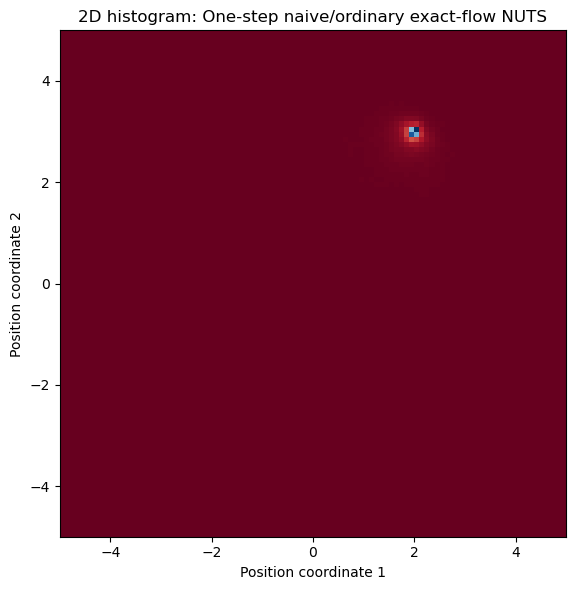

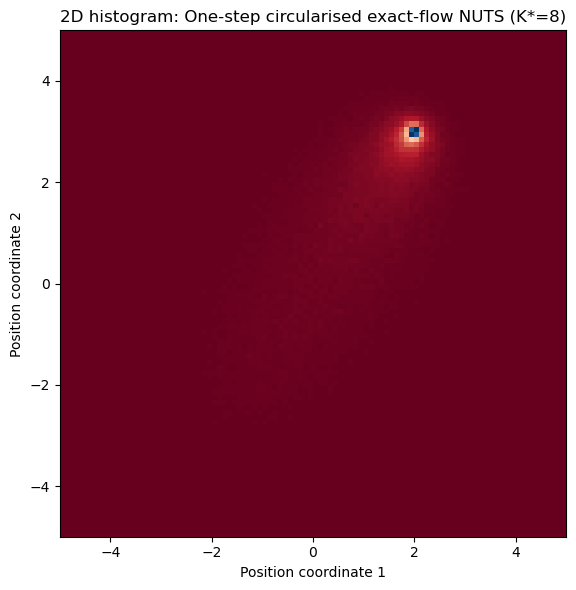

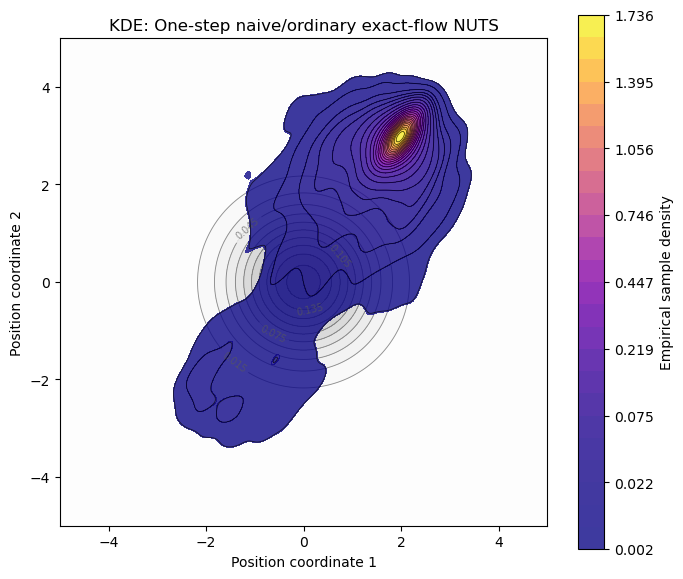

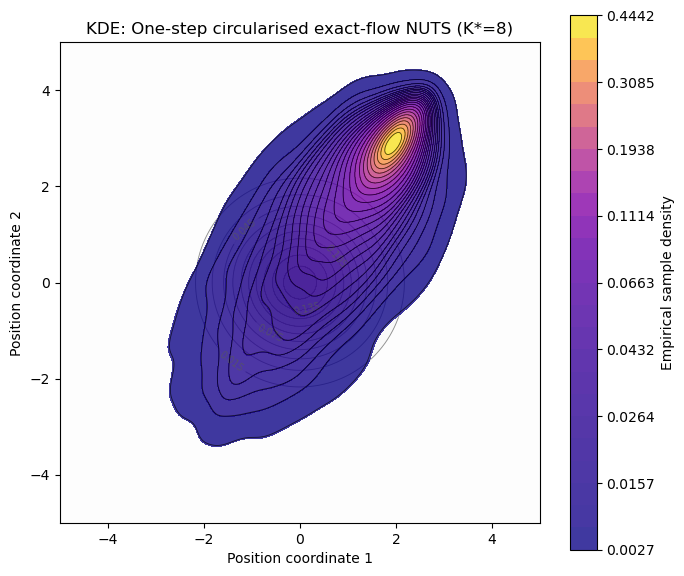

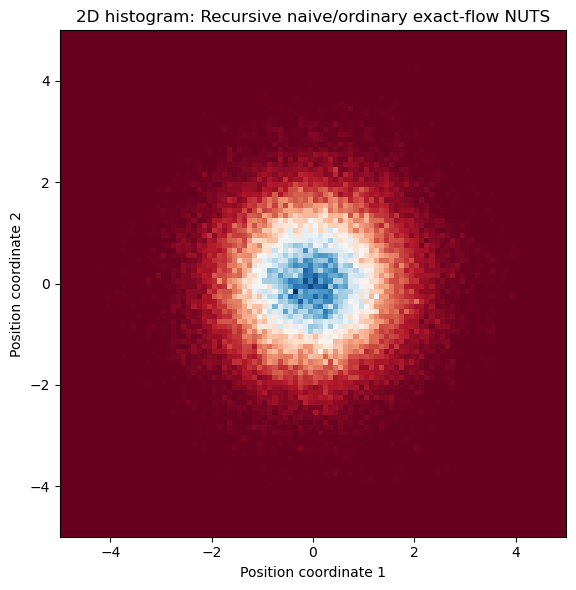

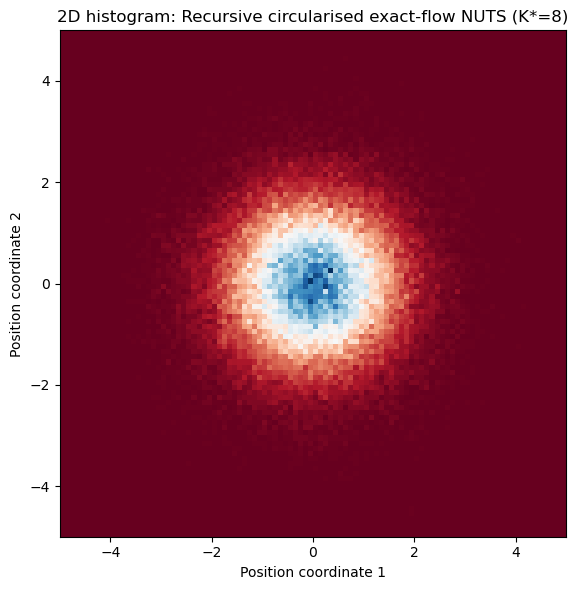

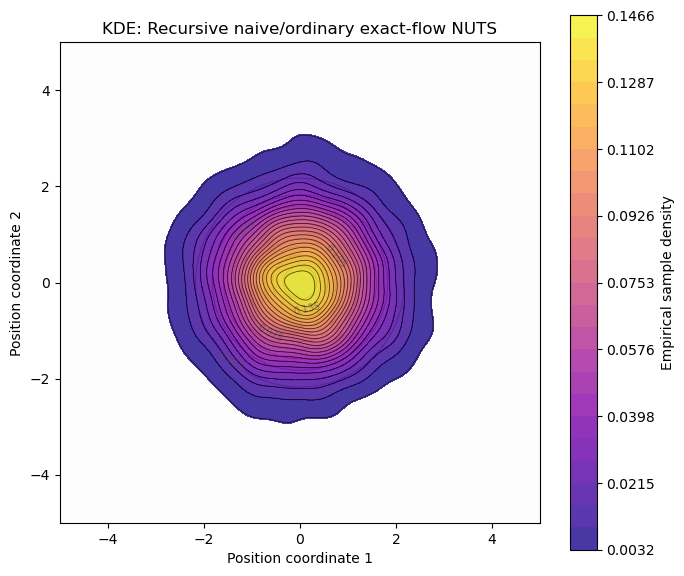

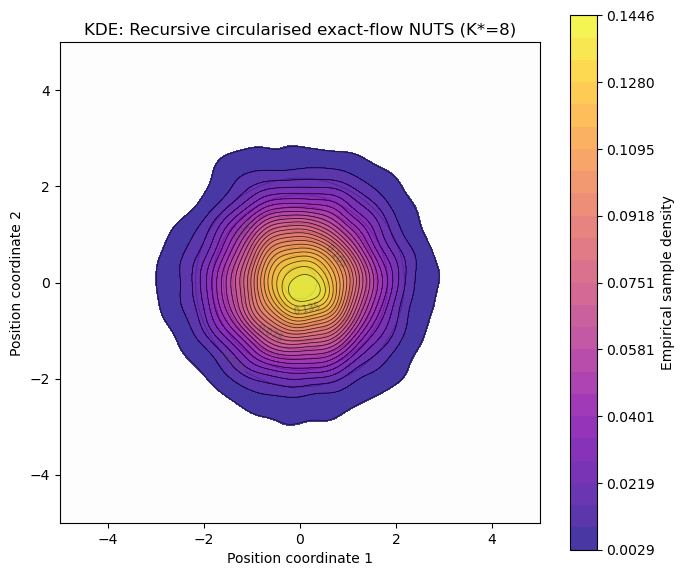

Naive: 222.908 seconds
Circularised: 0.008 seconds


In [10]:
RUN_SAMPLING_DIAGNOSTICS = True
RUN_SPEED_BENCHMARK = True

naive_para = {
    "A": None,
    "Sigma": np.eye(2),
    "epsilon": 0.01,
}

circ_para = {
    "d": 2,
    "sigma": 1.0,
    "epsilon": 0.01,
    "m": 1.0,
    "eta": 1.0,
}

x0 = np.array([2.0, 3.0])
n_samples = int(1e5)

if RUN_SAMPLING_DIAGNOSTICS:
    x0_hist = x0

    one_step_result = plot_sampler_eval(
        focus="1-step",
        x0=x0_hist,
        naive_para=naive_para,
        circ_para=circ_para,
        n_samples=n_samples,
        burn_in=0,
        plot_range=((-5, 5), (-5, 5)),
        max_depth=20,
        bins=100,
        plot_histogram=True,
        plot_kde=True,
        kde_max_points=10000,
        kde_levels=25,
        kde_bw_adjust=1.2,
        kde_thresh=0.02,
        kde_gridsize=250,
        kde_cut=3,
        seed=0,
    )

    full_result = plot_sampler_eval(
        focus="full",
        x0=x0_hist,
        naive_para=naive_para,
        circ_para=circ_para,
        n_samples=n_samples,
        burn_in=0,
        plot_range=((-5, 5), (-5, 5)),
        max_depth=20,
        bins=100,
        plot_histogram=True,
        plot_kde=True,
        kde_max_points=10000,
        kde_levels=25,
        kde_bw_adjust=1.2,
        kde_thresh=0.02,
        kde_gridsize=250,
        kde_cut=3,
        seed=1,
    )

if RUN_SPEED_BENCHMARK:
    from time import perf_counter

    x0_benchmark = x0

    start = perf_counter()
    _ = sample_naive_histogram(
        focus="1-step",
        x0=x0_benchmark,
        n_samples=n_samples,
        sigma=1.0,
        epsilon=0.01,
        seed=0,
    )
    naive_seconds = perf_counter() - start

    start = perf_counter()
    _, _ = sample_circularised_histogram(
        focus="1-step",
        x0=x0_benchmark,
        n_samples=n_samples,
        sigma=1.0,
        epsilon=0.01,
        seed=1,
    )
    circular_seconds = perf_counter() - start

    print(f"Naive: {naive_seconds:.3f} seconds")
    print(f"Circularised: {circular_seconds:.3f} seconds")

**Interpretation.** The fast circularised generator is exact for the tree implemented above: it samples the same random retained interval and the same uniform candidate index, but avoids constructing its 1024-point retained tree and 2048-point failed proposal. These histograms remain empirical diagnostics; stationarity of the trajectory-dependent weighted algorithm requires a separate invariance argument.

---

## Fast comparison of ordinary and weighted circularised NUTS

Only the weighted endpoint criterion is used here. For the exact isotropic flow,
\[
(x_b-x_a)^T Wp_a=(x_b-x_a)^TWp_b
=\frac{m}{\sigma}\sin\!\left(\frac{(b-a)\epsilon}{\sigma}\right).
\]
Consequently, the circularised stopping depth is deterministic and can be evaluated from the dyadic widths $2^k-1$ without constructing the recursive tree. For $\sigma=1$ and $\epsilon=0.1$, this gives $K^*=10$.


In [11]:
class FastExactFlowNUTS_Isotropic_Naive(
    ExactFlowNUTS_MultiD_Gaussian
):
    """Ordinary exact-flow NUTS with scalar midpoint tests."""

    def __init__(
        self,
        d,
        sigma=1.0,
        epsilon=0.1,
        rng=None,
        tol=1e-12,
    ):
        self.sigma = float(sigma)
        self._trajectory_invariants = None
        super().__init__(
            Sigma=self.sigma**2 * np.eye(d),
            epsilon=epsilon,
            rng=rng,
            tol=tol,
        )

    def one_tree(self, x0, p0, max_depth=20, return_sample=False):
        x0 = np.asarray(x0, dtype=float)
        p0 = np.asarray(p0, dtype=float)

        self._trajectory_invariants = (
            float(x0 @ x0),
            float(p0 @ p0),
            float(x0 @ p0),
        )

        try:
            return super().one_tree(
                x0=x0,
                p0=p0,
                max_depth=max_depth,
                return_sample=return_sample,
            )
        finally:
            self._trajectory_invariants = None

    def Uturn_info(self, a, b, x0, p0):
        if a > b:
            raise ValueError("Require a <= b in Uturn_info.")

        if self._trajectory_invariants is None:
            x0 = np.asarray(x0, dtype=float)
            p0 = np.asarray(p0, dtype=float)
            x_norm_sq = float(x0 @ x0)
            p_norm_sq = float(p0 @ p0)
            xp = float(x0 @ p0)
        else:
            x_norm_sq, p_norm_sq, xp = self._trajectory_invariants

        theta_mid = (
            0.5 * (a + b) * self.epsilon / self.sigma
        )
        h = 0.5 * (b - a) * self.epsilon / self.sigma

        sin_mid = np.sin(theta_mid)
        cos_mid = np.cos(theta_mid)

        # ||q||^2 at the midpoint.
        q_norm_sq = (
            p_norm_sq * cos_mid**2
            + (x_norm_sq / self.sigma**2) * sin_mid**2
            - 2.0 * (xp / self.sigma) * sin_mid * cos_mid
        )

        # y^T q at the midpoint.
        y_dot_q = (
            xp * np.cos(2.0 * theta_mid)
            + 0.5
            * (self.sigma * p_norm_sq - x_norm_sq / self.sigma)
            * np.sin(2.0 * theta_mid)
        )

        sin_h = np.sin(h)
        cos_h = np.cos(h)

        common_term = (
            2.0 * self.sigma * sin_h * cos_h * q_norm_sq
        )
        radial_term = 2.0 * sin_h**2 * y_dot_q

        left_test = float(common_term + radial_term)
        right_test = float(common_term - radial_term)

        fail_left = left_test < -self.tol
        fail_right = right_test < -self.tol

        failing_endpoints = []
        if fail_left:
            failing_endpoints.append(a)
        if fail_right:
            failing_endpoints.append(b)

        return {
            "valid": not (fail_left or fail_right),
            "block": (a, b),
            "left_test": left_test,
            "right_test": right_test,
            "fail_left": fail_left,
            "fail_right": fail_right,
            "failing_endpoints": failing_endpoints,
        }


In [12]:
def circularised_summary(
    sigma,
    epsilon=0.1,
    max_depth=20,
    tol=1e-12,
):
    """Exact stopping summary for the weighted criterion."""
    if sigma <= 0 or epsilon <= 0:
        raise ValueError("sigma and epsilon must be positive.")
    if max_depth < 0:
        raise ValueError("max_depth must be non-negative.")

    K_star = 0
    failed_width = None
    failed_size = None

    # The proposed tree after k doublings has 2^k points and
    # endpoint width 2^k - 1.
    for k in range(1, max_depth + 1):
        width = 2**k - 1
        test_value_without_m = (
            np.sin(width * epsilon / sigma) / sigma
        )

        if test_value_without_m < -tol:
            failed_width = width
            failed_size = 2**k
            break

        K_star += 1

    retained_size = 2**K_star
    retained_width = retained_size - 1

    if failed_width is None:
        E_T_obs = np.nan
        stop_reason = "max_depth"
    else:
        # Under the notebook's definition, the nearest index in the
        # failed newly generated half is uniform on {1,...,2^K}.
        E_T_obs = epsilon * (2**K_star + 1) / 2.0
        stop_reason = "full_tree_failed"

    return {
        "K_star": K_star,
        "E_K": float(K_star),
        "E_T_obs": float(E_T_obs),
        "retained_size": retained_size,
        "retained_width": retained_width,
        "failed_size": failed_size,
        "failed_width": failed_width,
        "stop_reason": stop_reason,
    }


def generate_common_random_numbers(n_rep, d, seed=0):
    """Momentum draws and independent seeds for doubling directions."""
    rng = np.random.default_rng(seed)
    p0_samples = rng.normal(size=(n_rep, d))
    direction_seeds = rng.integers(
        0,
        np.iinfo(np.uint32).max,
        size=n_rep,
        dtype=np.uint32,
    )
    return p0_samples, direction_seeds


In [13]:
def estimate_naive_EK_T(
    x0,
    sigma,
    epsilon,
    p0_samples,
    direction_seeds,
    max_depth=20,
):
    """Monte Carlo estimates for ordinary isotropic exact-flow NUTS."""
    x0 = np.asarray(x0, dtype=float)
    p0_samples = np.asarray(p0_samples, dtype=float)
    direction_seeds = np.asarray(direction_seeds)

    if x0.ndim != 1:
        raise ValueError("x0 must be one-dimensional.")
    if p0_samples.ndim != 2 or p0_samples.shape[1] != x0.size:
        raise ValueError("p0_samples has the wrong shape.")
    if direction_seeds.shape != (p0_samples.shape[0],):
        raise ValueError("direction_seeds has the wrong shape.")

    sampler = FastExactFlowNUTS_Isotropic_Naive(
        d=x0.size,
        sigma=sigma,
        epsilon=epsilon,
    )

    n_rep = p0_samples.shape[0]
    K_values = np.empty(n_rep, dtype=float)
    T_values = np.empty(n_rep, dtype=float)

    for i in range(n_rep):
        # Reusing this seed at each radius gives the same direction
        # sequence prefix for the corresponding repetition.
        sampler.rng = np.random.default_rng(int(direction_seeds[i]))
        result = sampler.one_tree(
            x0=x0,
            p0=p0_samples[i],
            max_depth=max_depth,
            return_sample=False,
        )
        K_values[i] = result['K_star']
        T_values[i] = result['T_obs']

    return {
        "E_K": float(np.mean(K_values)),
        "E_T_obs": float(np.nanmean(T_values)),
        "K_values": K_values,
        "T_obs_values": T_values,
    }


def comparison_over_radii(
    scale_vals,
    direction,
    sigma=1.0,
    epsilon=0.1,
    n_rep=100,
    seed=0,
    max_depth=20,
):
    scale_vals = np.asarray(scale_vals, dtype=float)
    direction = np.asarray(direction, dtype=float)

    direction_norm = np.linalg.norm(direction)
    if direction_norm == 0:
        raise ValueError("direction must be nonzero.")
    direction = direction / direction_norm

    if np.any(scale_vals <= 0):
        raise ValueError(
            "Use strictly positive radii because finite W is "
            "undefined at x0=0."
        )

    p0_samples, direction_seeds = generate_common_random_numbers(
        n_rep=n_rep,
        d=direction.size,
        seed=seed,
    )

    E_K_naive = np.empty(scale_vals.size)
    E_T_naive = np.empty(scale_vals.size)

    for i, radius in enumerate(scale_vals):
        naive = estimate_naive_EK_T(
            x0=radius * direction,
            sigma=sigma,
            epsilon=epsilon,
            p0_samples=p0_samples,
            direction_seeds=direction_seeds,
            max_depth=max_depth,
        )
        E_K_naive[i] = naive['E_K']
        E_T_naive[i] = naive['E_T_obs']

    circular = circularised_summary(
        sigma=sigma,
        epsilon=epsilon,
        max_depth=max_depth,
    )

    E_K_circular = np.full(scale_vals.size, circular['E_K'])
    E_T_circular = np.full(scale_vals.size, circular['E_T_obs'])

    return {
        "E_K_naive": E_K_naive,
        "E_K_circularised": E_K_circular,
        "E_T_obs_naive": E_T_naive,
        "E_T_obs_circularised": E_T_circular,
        "circularised_summary": circular,
    }


In [14]:
def plot_comparison(
    scale_vals,
    directions,
    sigma=1.0,
    epsilon=0.1,
    n_rep=100,
    seed=0,
    max_depth=20,
):
    results = []

    for direction in directions:
        result = comparison_over_radii(
            scale_vals=scale_vals,
            direction=direction,
            sigma=sigma,
            epsilon=epsilon,
            n_rep=n_rep,
            seed=seed,
            max_depth=max_depth,
        )
        results.append(result)

    plt.figure(figsize=(8, 5))
    for i, result in enumerate(results):
        plt.plot(
            scale_vals,
            result['E_K_naive'],
            label=f'direction {i + 1} (ordinary NUTS)',
        )
        plt.plot(
            scale_vals,
            result['E_K_circularised'],
            '--',
            label=f'direction {i + 1} (circularised NUTS)',
        )
    plt.xlabel(r'$\|x_0\|$')
    plt.ylabel(r'$\widehat{\mathbb{E}}[K^*\mid x_0]$')
    plt.title(
        rf'Ordinary and Circularised NUTS '
        rf'($\sigma={sigma}$, $\epsilon={epsilon}$, $N={n_rep}$)'
    )
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    for i, result in enumerate(results):
        plt.plot(
            scale_vals,
            result['E_T_obs_naive'],
            label=f'direction {i + 1} (ordinary NUTS)',
        )
        plt.plot(
            scale_vals,
            result['E_T_obs_circularised'],
            '--',
            label=f'direction {i + 1} (circularised NUTS)',
        )
    plt.xlabel(r'$\|x_0\|$')
    plt.ylabel(r'$\widehat{\mathbb{E}}[T_{\mathrm{obs}}\mid x_0]$')
    plt.title(
        rf'Ordinary and Circularised NUTS '
        rf'($\sigma={sigma}$, $\epsilon={epsilon}$, $N={n_rep}$)'
    )
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return results


In [15]:
# Validation against the original recursive circularised implementation.
summary = circularised_summary(
    sigma=1.0,
    epsilon=0.1,
    max_depth=20,
)
print(summary)
assert summary['K_star'] == 10
assert summary['retained_size'] == 1024
assert summary['retained_width'] == 1023
assert summary['failed_size'] == 2048
assert summary['failed_width'] == 2047

validation_rng = np.random.default_rng(123)
recursive_sampler = ExactFlowNUTS_MultiD_Gaussian_Circularised(
    d=2,
    sigma=1.0,
    epsilon=0.1,
    m=1.0,
    eta=1.0,
    rng=np.random.default_rng(456),
)

for _ in range(3):
    p0 = validation_rng.normal(size=2)
    result = recursive_sampler.one_tree(
        x0=np.array([1.0, 0.0]),
        p0=p0,
        max_depth=20,
        return_sample=False,
    )
    assert result['K_star'] == summary['K_star']

print('Recursive and analytic circularised depths agree.')

{'K_star': 10, 'E_K': 10.0, 'E_T_obs': 51.25, 'retained_size': 1024, 'retained_width': 1023, 'failed_size': 2048, 'failed_width': 2047, 'stop_reason': 'full_tree_failed'}
Recursive and analytic circularised depths agree.


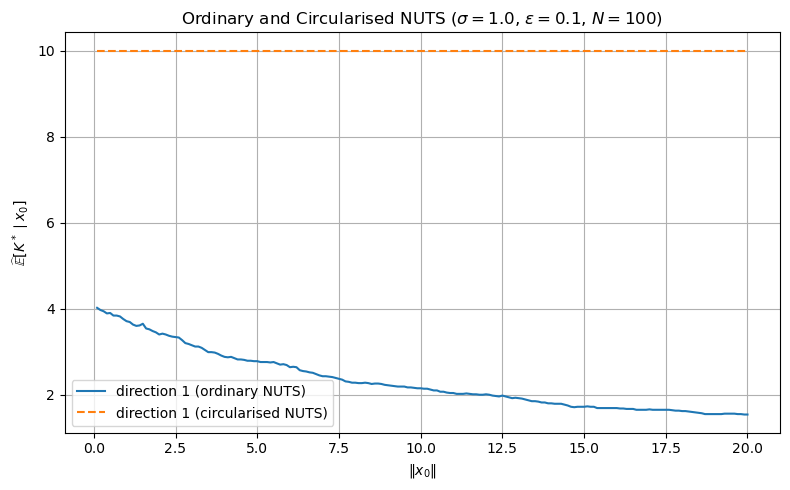

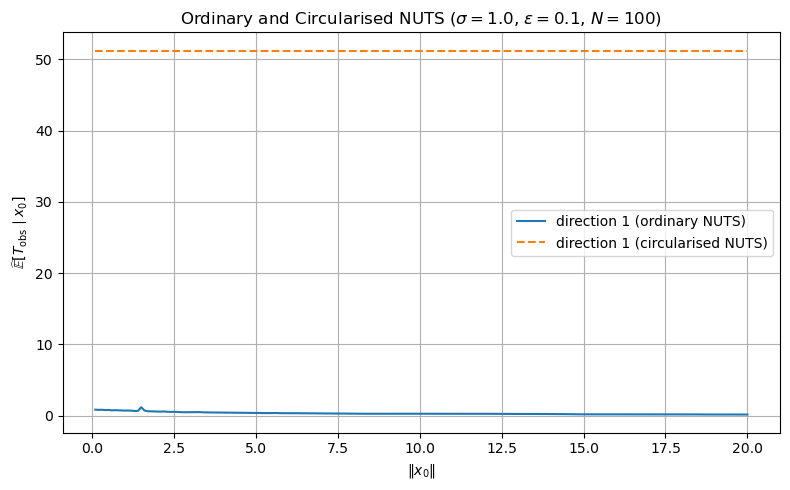

In [16]:
directions = [np.array([1.0, 0.0])]
scale_vals = np.linspace(0.1, 20.0, 200)

results = plot_comparison(
    scale_vals=scale_vals,
    directions=directions,
    sigma=1.0,
    epsilon=0.1,
    n_rep=100,
    seed=0,
    max_depth=20,
)


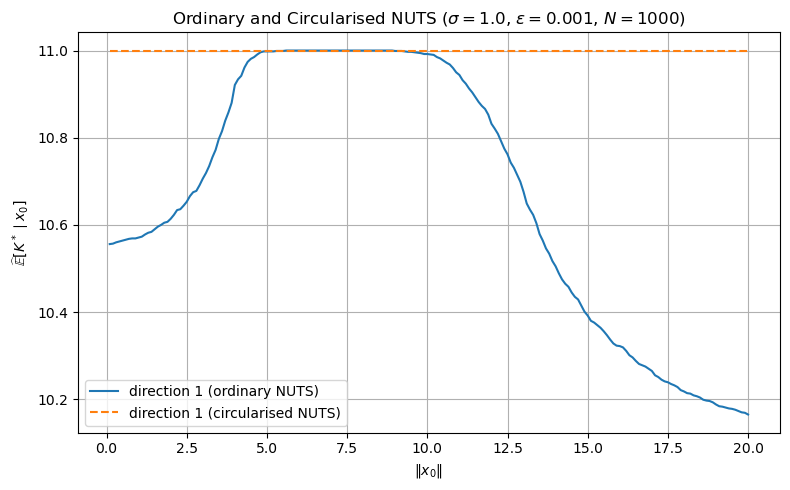

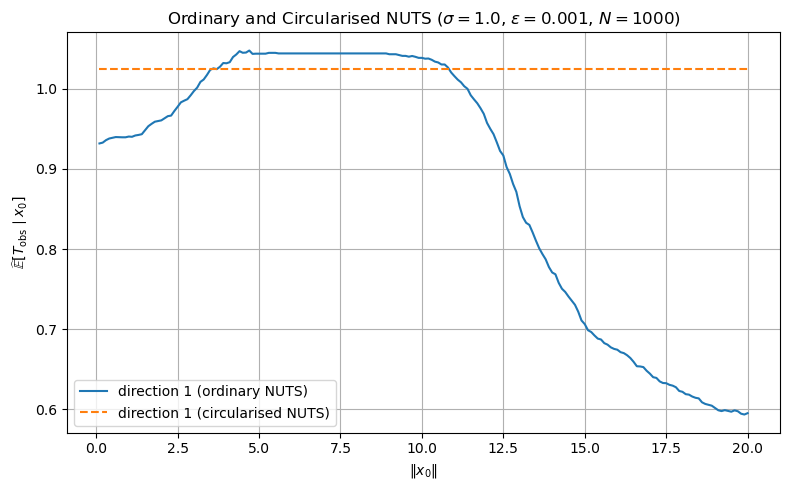

In [17]:
# Isotropic 50D covariance matrix
d = 50
directions_d = np.zeros(d)
directions_d[0] = 1.0  # axis direction

# Self-normalise the directions
directions_d = [directions_d / np.linalg.norm(directions_d)]

scale_vals = np.linspace(0.1, 20.0, 200)

results = plot_comparison(
    scale_vals=scale_vals,
    directions=directions_d,
    sigma=1.0,
    epsilon=0.001,
    n_rep=1000,
    seed=0,
    max_depth=20
)